In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping


In [3]:
##Load Feature-Engineered Data
X = np.load("X.npy")

print("X shape:", X.shape)


X shape: (7691, 30, 7)


In [4]:
##Train / Validation Split (Temporal)

split = int(0.8 * len(X))

X_train, X_val = X[:split], X[split:]

print("Train samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])


Train samples: 6152
Validation samples: 1539


In [5]:
## Dimension
TIMESTEPS = X.shape[1]
FEATURES = X.shape[2]


In [6]:
##LSTM AutoEncoder Model
autoencoder = Sequential([
    LSTM(64, input_shape=(TIMESTEPS, FEATURES), return_sequences=False),
    RepeatVector(TIMESTEPS),
    LSTM(64, return_sequences=True),
    TimeDistributed(Dense(FEATURES))
])

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()


D:\hyperscale\hyperscale_data_center\ai_models\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector (RepeatVector)         │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 30, 64)              │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 30, 7)               │             455 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,911 (202.78 KB)

 Trainable params: 51,911 (202.78 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
##Train Encoder
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_ae = autoencoder.fit(
    X_train, X_train,
    epochs=40,
    batch_size=64,
    validation_data=(X_val, X_val),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - loss: 0.0844 - val_loss: 0.0718
Epoch 2/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0700 - val_loss: 0.0697
Epoch 3/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0688 - val_loss: 0.0692
Epoch 4/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0686 - val_loss: 0.0690
Epoch 5/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0685 - val_loss: 0.0690
Epoch 6/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0683 - val_loss: 0.0688
Epoch 7/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0678 - val_loss: 0.0681
Epoch 8/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0673 - val_loss: 0.0676
Epoch 9/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0671 - val_loss: 0.0674
Epoch 10/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0668 - val_loss: 0.0673
Epoch 11/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0665 - val_loss: 0.0667
Epoch 12/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.

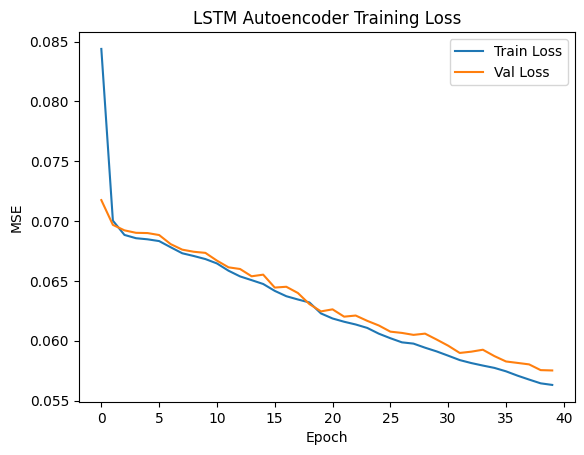

In [8]:
## Plot Training Loss
plt.plot(history_ae.history["loss"], label="Train Loss")
plt.plot(history_ae.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("LSTM Autoencoder Training Loss")
plt.legend()
plt.show()


In [9]:
##Reconstruction Error Calculation
X_val_pred = autoencoder.predict(X_val)

reconstruction_error = np.mean(
    np.square(X_val - X_val_pred),
    axis=(1, 2)
)


49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


In [10]:
## Anomaly Threshold

threshold = np.percentile(reconstruction_error, 95)

print("Anomaly threshold:", threshold)


Anomaly threshold: 0.07161511837512143


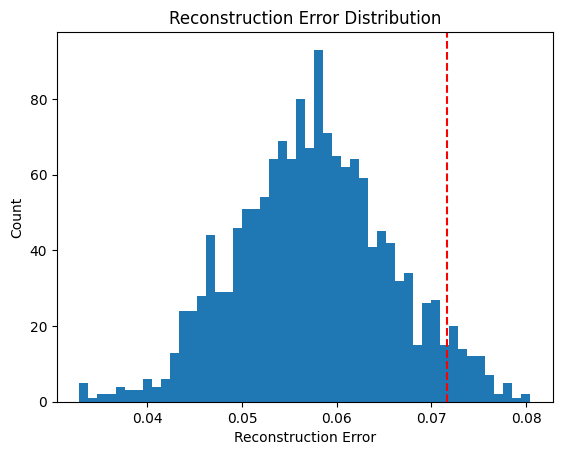

In [12]:
##Error Distribution
plt.hist(reconstruction_error, bins=50)
plt.axvline(threshold, color="red", linestyle="--")
plt.title("Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.show()


In [13]:
## Detect Anomaly
anomalies = reconstruction_error > threshold

print("Total validation samples:", len(reconstruction_error))
print("Detected anomalies:", anomalies.sum())


Total validation samples: 1539
Detected anomalies: 77


In [14]:
##Inspect Anomalous Sequences
anomaly_indices = np.where(anomalies)[0][:5]

for idx in anomaly_indices:
    print(f"Anomaly at index {idx} → error = {reconstruction_error[idx]:.5f}")


Anomaly at index 61 → error = 0.07285
Anomaly at index 62 → error = 0.07197
Anomaly at index 63 → error = 0.07454
Anomaly at index 73 → error = 0.07534
Anomaly at index 74 → error = 0.07491


In [15]:
##Save Autoencoder Model
autoencoder.save("lstm_autoencoder_model.h5")


In [16]:
##Save Threshold for Inference
np.save("anomaly_threshold.npy", threshold)

In [17]:
##“An LSTM-based autoencoder was trained on normal operating telemetry to detect anomalies using reconstruction error thresholds without requiring labeled fault data.”